In [ ]:
# part 1

In [2]:
# Function to compute the marginal probability (the total probability of observing the evidence)
def compute_marginal(likelihood_rain, prior_rain, likelihood_no_rain, prior_no_rain):
    """
    Calculates the marginal probability of the evidence:
    P(Evidence) = P(Evidence | Rain) * P(Rain) + P(Evidence | No Rain) * P(No Rain)
    """
    return likelihood_rain * prior_rain + likelihood_no_rain * prior_no_rain

In [3]:
# Function to compute the posterior probability using Bayes' Theorem
def compute_posterior(prior_rain, likelihood_evidence_given_rain, likelihood_evidence_given_no_rain):
    """
    Applies Bayes' Theorem:
    P(Rain | Evidence) = [P(Evidence | Rain) * P(Rain)] / P(Evidence)
    Returns: posterior probability and marginal probability
    """
    prior_no_rain = 1 - prior_rain  # Since P(No Rain) = 1 - P(Rain)
    marginal = compute_marginal(
        likelihood_evidence_given_rain, prior_rain,
        likelihood_evidence_given_no_rain, prior_no_rain
    )
    posterior = (likelihood_evidence_given_rain * prior_rain) / marginal
    return posterior, marginal

In [6]:
# Display the results of Bayesian inference clearly
def display_results(condition, prior, likelihood_rain, likelihood_no_rain):
    """
    Wrapper to compute and print prior, likelihoods, marginal, and posterior nicely.
    """
    posterior, marginal = compute_posterior(prior, likelihood_rain, likelihood_no_rain)

    print(f"\n Condition: {condition}")
    print(f"Prior P(Rain): {prior}")
    print(f"Likelihood P({condition} | Rain): {likelihood_rain}")
    print(f"Likelihood P({condition} | No Rain): {likelihood_no_rain}")
    print(f"Marginal P({condition}): {round(marginal, 3)}")
    print(f"Posterior P(Rain | {condition}): {round(posterior, 3)}")


In [7]:
#  high humidity case

prior_rain = 0.3  # Prior belief that it rains
likelihood_high_given_rain = 0.8  # P(High Humidity | Rain)
likelihood_high_given_no_rain = 0.2  # P(High Humidity | No Rain)

display_results(
    condition="High Humidity",
    prior=prior_rain,
    likelihood_rain=likelihood_high_given_rain,
    likelihood_no_rain=likelihood_high_given_no_rain
)


 Condition: High Humidity
Prior P(Rain): 0.3
Likelihood P(High Humidity | Rain): 0.8
Likelihood P(High Humidity | No Rain): 0.2
Marginal P(High Humidity): 0.38
Posterior P(Rain | High Humidity): 0.632


In [8]:
# Not high humidity case

# Using complement probabilities for "not high humidity"
likelihood_low_given_rain = 1 - likelihood_high_given_rain  # = 0.2
likelihood_low_given_no_rain = 1 - likelihood_high_given_no_rain  # = 0.8

display_results(
    condition="Not High Humidity",
    prior=prior_rain,
    likelihood_rain=likelihood_low_given_rain,
    likelihood_no_rain=likelihood_low_given_no_rain
)


 Condition: Not High Humidity
Prior P(Rain): 0.3
Likelihood P(Not High Humidity | Rain): 0.19999999999999996
Likelihood P(Not High Humidity | No Rain): 0.8
Marginal P(Not High Humidity): 0.62
Posterior P(Rain | Not High Humidity): 0.097


In [ ]:
# part 3

# Part 3 & 4



This part demonstrates the Gradient Descent algorithm applied to a simple linear regression model. The section is divided into two main parts:

1.  **Part 3: Manual Calculations:** Performing step-by-step calculations of Gradient Descent updates for the parameters ($m$ and $b$).
2.  **Part 4:Code Implementation and Visualization:** Automating those steps with Python and visualizing the changes.

## Objective

Given a simple dataset, we aim to find the best-fit line using gradient descent to minimize the Mean Squared Error (MSE) by updating the slope (`m`) and y-intercept (`b`) iteratively.

---

## Manual Calculation Summary

We used the following gradient descent formulas:

- Predicted: \( \hat{y}_i = m x_i + b \)
- MSE: \( J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \)
- Gradients:
  - mnew = mold − α(∂b\∂m)
  - \( \frac{\partial J}{\partial b} = -\frac{2}{n} \sum (y_i - \hat{y}_i) \)
- Updates:
  - \( m := m - \alpha \cdot \frac{\partial J}{\partial m} \)
  - \( b := b - \alpha \cdot \frac{\partial J}{\partial b} \)

We applied these formulas over four iterations, updating `m` and `b` each time.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 3])
Y = np.array([3, 6])

m = -1
b = 1
alpha = 0.1
n = len(X)

m_history = [m]
b_history = [b]
error_history = []

print("--- Gradient Descent Simulation Setup ---")
print(f"Initial slope (m): {m}, Initial y-intercept (b): {b}")
print(f"Learning Rate (alpha): {alpha}")
print(f"Data Points: {list(zip(X, Y))}")
print(f"Number of data points (n): {n}\n")

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

print("Setup complete. Ready to begin iterations.")

--- Gradient Descent Simulation Setup ---
Initial slope (m): -1, Initial y-intercept (b): 1
Learning Rate (alpha): 0.1
Data Points: [(1, 3), (3, 6)]
Number of data points (n): 2

Setup complete. Ready to begin iterations.


In [ ]:
num_iterations = 4

print(f"Starting Gradient Descent for {num_iterations} iterations...\n")

for iteration in range(1, num_iterations + 1):
    print(f"--- Iteration {iteration} ---")
    print(f"  Current parameters: m = {m:.4f}, b = {b:.4f}")

    y_pred = m * X + b
    print(f"  Computed predicted y_hat values: {y_pred}")

    errors = Y - y_pred
    print(f"  Individual errors (Y - y_hat): {errors}")

    current_mse = calculate_mse(Y, y_pred)
    error_history.append(current_mse)
    print(f"  Mean Squared Error (MSE): {current_mse:.4f}")

    sum_term_dm = np.sum(errors * X)
    dJ_dm = (-2 / n) * sum_term_dm
    print(f"  Gradient (dJ/dm): {dJ_dm:.4f}")

    sum_term_db = np.sum(errors)
    dJ_db = (-2 / n) * sum_term_db
    print(f"  Gradient (dJ/db): {dJ_db:.4f}")

    m = m - alpha * dJ_dm
    b = b - alpha * dJ_db
    print(f"  Updated parameters: m = {m:.4f}, b = {b:.4f}")

    m_history.append(m)
    b_history.append(b)

    print("-" * 40)

print("\n--- Gradient Descent Process Completed ---")
print(f"Final slope (m): {m:.4f}, Final intercept (b): {b:.4f}")

Starting Gradient Descent for 4 iterations...

--- Iteration 1 ---
  Current parameters: m = -1.0000, b = 1.0000
  Computed predicted y_hat values: [ 0 -2]
  Individual errors (Y - y_hat): [3 8]
  Mean Squared Error (MSE): 36.5000
  Gradient (dJ/dm): -27.0000
  Gradient (dJ/db): -11.0000
  Updated parameters: m = 1.7000, b = 2.1000
----------------------------------------
--- Iteration 2 ---
  Current parameters: m = 1.7000, b = 2.1000
  Computed predicted y_hat values: [3.8 7.2]
  Individual errors (Y - y_hat): [-0.8 -1.2]
  Mean Squared Error (MSE): 1.0400
  Gradient (dJ/dm): 4.4000
  Gradient (dJ/db): 2.0000
  Updated parameters: m = 1.2600, b = 1.9000
----------------------------------------
--- Iteration 3 ---
  Current parameters: m = 1.2600, b = 1.9000
  Computed predicted y_hat values: [3.16 5.68]
  Individual errors (Y - y_hat): [-0.16  0.32]
  Mean Squared Error (MSE): 0.0640
  Gradient (dJ/dm): -0.8000
  Gradient (dJ/db): -0.1600
  Updated parameters: m = 1.3400, b = 1.9160



--- Final Predictions ---
  x = 1 → Predicted y = 3.2304, Actual y = 3
  x = 3 → Predicted y = 5.8976, Actual y = 6
Final Mean Squared Error: 0.0318


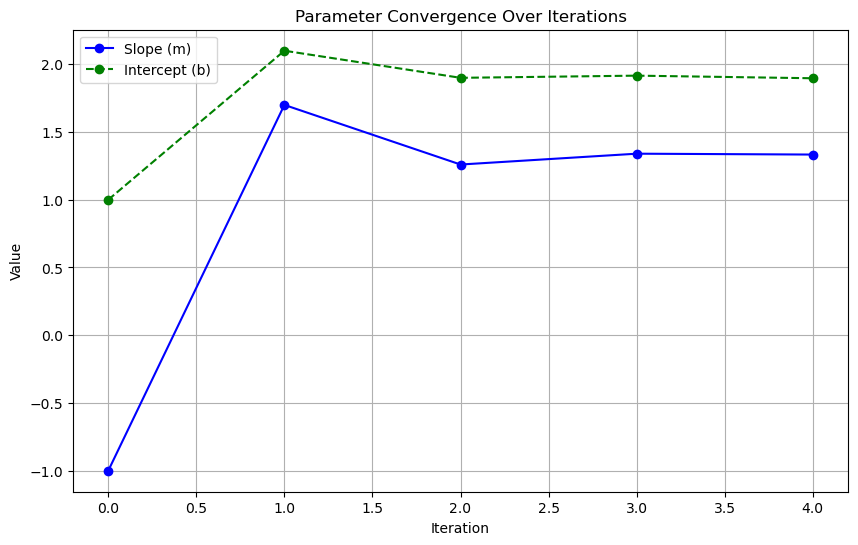

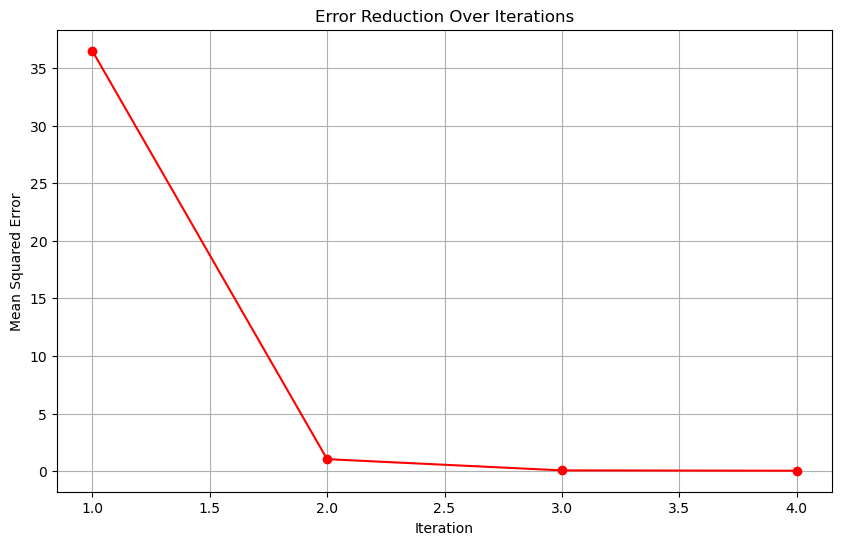


Plots generated. Observe parameter convergence and error reduction.


In [ ]:
print("\n--- Final Predictions ---")
final_y_pred = m * X + b
for i, x_val in enumerate(X):
    print(f"  x = {x_val} → Predicted y = {final_y_pred[i]:.4f}, Actual y = {Y[i]}")

final_mse = calculate_mse(Y, final_y_pred)
print(f"Final Mean Squared Error: {final_mse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(len(m_history)), m_history, 'o-', label='Slope (m)', color='blue')
plt.plot(range(len(b_history)), b_history, 'o--', label='Intercept (b)', color='green')
plt.title('Parameter Convergence Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_iterations + 1), error_history, 'o-', label='MSE', color='red')
plt.title('Error Reduction Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

print("\nPlots generated. Observe parameter convergence and error reduction.")